### 0. Wstęp

Ta część kodu dotyczy modeli które uczą się i są testowane na plikach .npy z folderu Spectrograms. 
Folder ten zawiera tablice numpy o wymiarach 128 x 128, które są MEL-spektrogramami z 3 sekondowych wycinków utworów

Porównane zostaną 
- MLP na spłaszczonym spektrogramie (długość az 128 x 128)
- Standardowa sieć CNN o wejściu 128 x 128 z klasyfikatorem MLP na końcu
- Głęboka sieć z połączeniami rezydualnymi, podobna do znanej sieci ResNet18, ale dostosowana do uzywanych tu wymiarów

Plik wykorzystuje $good\_labels.csv$, które odpowiadają plikom z $labels.csv$, które udało się przetransformować na niepusty spektrogram.
Do track_id z $labels.csv$ dodano końcówki $\_s1$, $\_s2$, $\_s3$, poniewaz kazdy utwór otrzymał 3 utwory-dzieci 

### Czym jest spektrogram i jak rózne parametry wpływają na zachowanie spektrogramu?
$Spektrogram$ to reprezentacja dźwięku w domenie czas–częstotliwość. Zamiast patrzeć na sygnał audio jako na jednowymiarową falę 
x[n], dzielimy go na krótkie fragmenty (okna czasowe) i dla każdego fragmentu liczymy, jakie częstotliwości są w nim obecne. 
Technicznie robimy to przez krótkookresową transformatę Fouriera


OŚ X:
- $seconds$ - ile sekund dzwięku wsadzamy do spektrogramu (nie jest to równoznaczne z osią X, zalezy ona od dalszych paramertów)
- $sr$ - z jaką częstotliwością nagrywany był dźwięk (odpowiednik frames per second dla filmu) 
$sr / 2$ to maksymalna częstotliwość którą komputer moze wyreprezentować
całe nagranie dla komputera ma zatem $seconds * sr$ "kratek"
- $hop\_length$ o ile kratek przesuwamy okno transormaty fouriera w czasie jednej sekundy.
Im mniejszy hop-length tym gęstsza oś X


OŚ Y:

- $n\_mels$ - na ile kubełków dzielimy zakres częstotliwości (do niej wpadają poszczególne sygnały w wykorzystywanej transformacie fouriera)
- $f\_min$, $f\_max$ - zakres interesującej nas częstotliwości



Uzywane spektrogramy wytworzone były wg ponizszego przepisu z wykorzystaniem funkcji $librosa.feature.melspectrogram$
```python
    seconds: float = 3.0,
    sr: int = 22050,
    n_mels: int = 128,
    n_fft: int = 2048,
    hop_length: int = 512,
    fmin: float = 20.0,
    fmax: float | None = 8000.0,
    top_db: float = 80.0,
    time_bins: int = 128,
    seed: int | None = None,


wymagania systemowe:

pytorch,
torchview, (wizualizacja sieci)

## 0. Przygotowanie danych i przydatnych funkcji

### 0.1 konfig oraz przygotowanie danych

In [ ]:
#naprawa wyskakującego błędu
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

#importy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import random

#konfiguracja modelu i ustawienie danych wejściowych
class Config:
    CSV_PATH = 'good_labels.csv'
    SPECTROGRAMS_DIR = 'spectrograms'
    
    IMG_HEIGHT = 128
    IMG_WIDTH = 128
    INPUT_SIZE = IMG_HEIGHT * IMG_WIDTH 
    
    SEED = 123
    BATCH_SIZE = 64         
    LEARNING_RATE = 0.0002    
    EPOCHS = 30               
    
    random.seed(SEED)
    np.random.seed(SEED)

    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

#sprawdzenie poprawności i przygotowanie danych
def prepare_data():
    """
    Funkcja przygotowuje dane do treningu.
    1. Sprawdza istnienie odpowiedniego folderu z plikami .npy
    2. Sprawdza ile plików ma dostępny label
    3. Zakodowuje klasy za pomocą sklearn.LabelEncoder
    4. Dzieli dane na zbiór testowy i treningowy (według ID piosenek - rodziców. Kazdy z nich wygenerował 3 spektrogramy)
    5. Zwraca przygotowane dane
    """
    print("[KROK 1] Weryfikacja danych...")

    # czy jest tu wgl plik
    
    if not os.path.exists(Config.SPECTROGRAMS_DIR):
        raise FileNotFoundError(f"BŁĄD: Nie znaleziono folderu '{Config.SPECTROGRAMS_DIR}'!")
    if not os.path.exists(Config.CSV_PATH):
        raise FileNotFoundError(f"BŁĄD: Nie znaleziono pliku '{Config.CSV_PATH}'!")



    df = pd.read_csv(Config.CSV_PATH, dtype={'track_id': str})
    
    def check_file_exists(track_id):
        path = os.path.join(Config.SPECTROGRAMS_DIR, f"{track_id}.npy")
        return os.path.exists(path)

    print("   -> Sprawdzam spójność plików...")
    df['file_exists'] = df['track_id'].apply(check_file_exists)
    df_clean = df[df['file_exists'] == True].copy()
    
    print(f"   -> Znaleziono: {len(df_clean)} plików .npy.")
    if len(df_clean) == 0:
        raise RuntimeError("BŁĄD KRYTYCZNY: Folder pusty lub złe nazwy plików!")

    le = LabelEncoder()
    labels_encoded = le.fit_transform(df_clean['track_genre'])
    
    X_ids = df_clean['track_id'].values
    y_labels = labels_encoded
    
    ########## dzielimy tracki na treningowy i testowy po parent_id - inaczej mielibyśmy information leak między testowym a treningowym
        
    parent_ids = np.array([tid[:6] for tid in X_ids], dtype=str)   # or tid.split("_")[0]


    unique_parents, first_idx = np.unique(parent_ids, return_index=True)
    y_parent = y_labels[first_idx]

 
    parent_train, parent_test, y_parent_train, y_parent_test = train_test_split(
        unique_parents,
        y_parent,
        test_size=0.2,
        random_state=Config.SEED,
        stratify=y_parent,
    )


    train_mask = np.isin(parent_ids, parent_train)
    test_mask  = np.isin(parent_ids, parent_test)

    X_train_ids = X_ids[train_mask]
    y_train     = y_labels[train_mask]

    X_test_ids  = X_ids[test_mask]
    y_test      = y_labels[test_mask]
    ##########
    
    num_classes = len(le.classes_)
    return X_train_ids, X_test_ids, y_train, y_test, le, num_classes




### 0.2 Obiekty $Dataset$ dla modeli typu CNN oraz MLP

In [12]:
#wgranie datasetu

class SpectrogramDataset(Dataset):
    def __init__(self, track_ids, labels, root_dir):
        self.track_ids = track_ids
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.root_dir = root_dir
        
    def __len__(self):
        return len(self.track_ids)
    
    def __getitem__(self, idx):
        track_id = self.track_ids[idx]
        file_path = os.path.join(self.root_dir, f"{track_id}.npy")
        
        spectrogram = np.load(file_path).astype(np.float32)


            
        return torch.from_numpy(spectrogram), self.labels[idx]
    

class SpectrogramCnnDataset(SpectrogramDataset):
    """
    Dziedziczy z klasy SpectrogramDataset:
    - zmienia wymiary zwracanego tensora (Wysokosc, Szerokość) -> (Channels (tu greyscale wiec 1), Wysokość, Szekoroksc)
    - dodana vizualizacja wybranego po indeksie spektrogramu
    """
    def __init__(self, track_ids, labels, root_dir):
        super().__init__(track_ids, labels, root_dir)

    def __getitem__(self, idx):
        x, y = super().__getitem__(idx)
        if x.ndim == 2:
            x = x.unsqueeze(0)
        return x, y

    def visualise(self, idx, title=None, cmap="gray"):
        """
        Wizualizacja spektrogramu
        """
        item = self[idx]
        x, y = item
        tid = self.track_ids[idx]


        img = x[0].cpu().numpy() if x.ndim == 3 else x.cpu().numpy()

        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img, aspect="auto", origin="lower", cmap=cmap)
        if title is None:
            ax.set_title(f"track_id={tid} | label={int(y)}", fontsize=9)
        else:
            ax.set_title(title, fontsize=9)
        ax.axis("off")
        plt.show()

        return x, y

### 0.3 Funkcja Ewaluacyjna

In [ ]:
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd

from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def model_training_and_eval(
    model_class,
    dataset,
    optim_algo=optim.Adam,
    n_runs: int = 3,
    base_seed: int = 42,
):
    """
    funkcja przyjmuje klasę modelu, obiekt dataset, liczbę wykonań oraz optimiser i wykonuje ponizsze kroki
    1. przygotowuje dane (podział na dane testowe i treningowe jest według jednego ziarna, więc dla porządku jest to w środku funkcji)
    2. Tworzy instancje modelu
    3. Przesuwa ją na odpowiednie urządzenie na komputerze
    4. Dla kazdej z 30 epok wykonuje trening oraz ewaluacje modeli. To jak zmienia się funkcja straty i accuracy jest raportowane na wykresie
    (proces jest powtarzany n_runs razy i na wykresie widnieją średnie + odchylenia standardowe)
    5. Na wykresie zaznacza najlepszą epokę. 
    6. Z ostatniego runu najlepszej epoki raportuje macierz pomyłek oraz miary ewaluacyjne.
    """
    # przygotowuję dane
    X_train_ids, X_test_ids, y_train, y_test, le, num_classes = prepare_data()

    # sprawdzam przyśpieszacz
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print("Using device:", device)

    all_histories = []

    # zbieram informacje o ostatniej epoce w zmiennych
    last_run_epoch_states = None
    last_run_seed = None

    for run in range(n_runs):
        seed = base_seed + run
        last_run_seed = seed
        set_seed(seed)

        # zalezy nam aby porządek ustalony w kazdej epoce był deterministyczny 
        g = torch.Generator()
        g.manual_seed(seed)

        train_loader = DataLoader(
            dataset(X_train_ids, y_train, Config.SPECTROGRAMS_DIR),
            batch_size=Config.BATCH_SIZE,
            shuffle=True,
            generator=g
        )
        test_loader = DataLoader(
            dataset(X_test_ids, y_test, Config.SPECTROGRAMS_DIR),
            batch_size=Config.BATCH_SIZE,
            shuffle=False
        )

        model = model_class(input_size=Config.INPUT_SIZE, num_classes=num_classes).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim_algo(model.parameters(), lr=Config.LEARNING_RATE)

        history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    
        if run == n_runs - 1:
            last_run_epoch_states = []

        print(f"\n=== RUN {run+1}/{n_runs} (seed={seed}) | {model.__class__.__name__} | {optim_algo.__name__} ===")

        for epoch in range(Config.EPOCHS):


            # ---- FAZA TRENINGU ----
            model.train()
            running_train_loss = 0.0
            correct_train = 0
            total_train = 0

            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_train_loss += loss.item() * labels.size(0)
                pred = outputs.argmax(dim=1)
                total_train += labels.size(0)
                correct_train += (pred == labels).sum().item()

            epoch_train_loss = running_train_loss / total_train
            epoch_train_acc = 100 * correct_train / total_train

            # ---- FAZA TESTU ----
            model.eval()
            running_test_loss = 0.0
            correct_test = 0
            total_test = 0

            with torch.no_grad():
                for images, labels in test_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                    running_test_loss += loss.item() * labels.size(0)
                    pred = outputs.argmax(dim=1)
                    total_test += labels.size(0)
                    correct_test += (pred == labels).sum().item()

            epoch_test_loss = running_test_loss / total_test
            epoch_test_acc = 100 * correct_test / total_test

            history["train_loss"].append(epoch_train_loss)
            history["train_acc"].append(epoch_train_acc)
            history["test_loss"].append(epoch_test_loss)
            history["test_acc"].append(epoch_test_acc)

            print(
                f"Epoka {epoch+1:02d} | "
                f"Train Loss: {epoch_train_loss:.4f} Test Loss: {epoch_test_loss:.4f} | "
                f"Train Acc: {epoch_train_acc:.2f}% Test Acc: {epoch_test_acc:.2f}%"
            )

        
            if run == n_runs - 1:
                last_run_epoch_states.append({k: v.detach().cpu().clone() for k, v in model.state_dict().items()})

        all_histories.append(history)

    # ---- AGREGACJA STATYSTYK DLA EPOKI ----
    def stack(key):
        return np.array([h[key] for h in all_histories], dtype=float)  # (n_runs, epochs)

    train_loss = stack("train_loss")
    test_loss  = stack("test_loss")
    train_acc  = stack("train_acc")
    test_acc   = stack("test_acc")

    tl_m = train_loss.mean(axis=0)
    vl_m = test_loss.mean(axis=0)
    ta_m = train_acc.mean(axis=0)
    va_m = test_acc.mean(axis=0)

    tl_s = train_loss.std(axis=0, ddof=1) if n_runs > 1 else np.zeros_like(tl_m)
    vl_s = test_loss.std(axis=0, ddof=1) if n_runs > 1 else np.zeros_like(vl_m)
    ta_s = train_acc.std(axis=0, ddof=1) if n_runs > 1 else np.zeros_like(ta_m)
    va_s = test_acc.std(axis=0, ddof=1) if n_runs > 1 else np.zeros_like(va_m)

    epochs = np.arange(1, Config.EPOCHS + 1)

    # ---- KTÓRA EPOKA MA NAJLEPSZY TEST ACCURACY? ----
    best_epoch_idx = int(np.argmax(va_m))          # 0-based
    best_epoch = best_epoch_idx + 1                # 1-based
    print(f"\nBest epoch by AVERAGE Test Acc across runs: epoch {best_epoch} | mean Test Acc = {va_m[best_epoch_idx]:.2f}%")

    # ---- Plot mean ± std ----
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    ax[0].plot(epochs, tl_m, label="Train Loss")
    ax[0].fill_between(epochs, tl_m - tl_s, tl_m + tl_s, alpha=0.2)
    ax[0].plot(epochs, vl_m, label="Test Loss", linestyle="--")
    ax[0].fill_between(epochs, vl_m - vl_s, vl_m + vl_s, alpha=0.2)
    ax[0].axvline(best_epoch, linestyle=":", label=f"Best avg epoch = {best_epoch}")
    ax[0].set_title("Loss (mean ± std)")
    ax[0].set_xlabel("Epoka")
    ax[0].set_ylabel("Loss")
    ax[0].grid(True)
    ax[0].legend()

    ax[1].plot(epochs, ta_m, label="Train Acc")
    ax[1].fill_between(epochs, ta_m - ta_s, ta_m + ta_s, alpha=0.2)
    ax[1].plot(epochs, va_m, label="Test Acc", linestyle="--")
    ax[1].fill_between(epochs, va_m - va_s, va_m + va_s, alpha=0.2)
    ax[1].axvline(best_epoch, linestyle=":", label=f"Best avg epoch = {best_epoch}")
    ax[1].set_title("Accuracy (mean ± std)")
    ax[1].set_xlabel("Epoka")
    ax[1].set_ylabel("Accuracy (%)")
    ax[1].grid(True)
    ax[1].legend()

    os.makedirs("wyniki_avg", exist_ok=True)
    model_name = model_class.__name__ if hasattr(model_class, "__name__") else "model"
    fig.suptitle(f"{model_name} | optimiser: {optim_algo.__name__} | runs={n_runs}")
    fig.savefig(f"wyniki_avg/{model_name}_{optim_algo.__name__}_runs{n_runs}_mean_std.png", dpi=200, bbox_inches="tight")
    plt.show()

    # ---- Confusion matrix + classification report for LAST RUN at epoch = best_epoch ----
    # Rebuild loaders for last seed (not strictly necessary, but keeps everything aligned)
    set_seed(last_run_seed)
    test_loader_last = DataLoader(
        dataset(X_test_ids, y_test, Config.SPECTROGRAMS_DIR),
        batch_size=Config.BATCH_SIZE,
        shuffle=False
    )

    model_last = model_class(input_size=Config.INPUT_SIZE, num_classes=num_classes).to(device)
    model_last.load_state_dict(last_run_epoch_states[best_epoch_idx])
    model_last.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader_last:
            images, labels = images.to(device), labels.to(device)
            outputs = model_last(images)
            pred = outputs.argmax(dim=1)
            all_preds.extend(pred.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(le.classes_))))
    print("\nConfusion matrix (LAST RUN @ best avg epoch):")
    print(pd.DataFrame(cm, index=le.classes_, columns=le.classes_))

    print("\nClassification report (LAST RUN @ best avg epoch):")
    print(classification_report(all_labels, all_preds, target_names=le.classes_))

    # optionally save those too
    out_dir = os.path.join("wyniki_avg", f"wyniki_{model_name}_avgBestEpoch")
    os.makedirs(out_dir, exist_ok=True)
    pd.DataFrame(cm, index=le.classes_, columns=le.classes_).to_csv(os.path.join(out_dir, "confusion_matrix.csv"))
    rep_df = pd.DataFrame(classification_report(all_labels, all_preds, target_names=le.classes_, output_dict=True)).transpose()
    rep_df.to_csv(os.path.join(out_dir, "report.csv"))

    return {
        "histories": all_histories,
        "best_epoch_by_mean": best_epoch,
        "best_epoch_mean_test_acc": float(va_m[best_epoch_idx]),
        "confusion_matrix": cm,
        "classification_report_df": rep_df,
    }


### 0.4 Funkcja ilustrująca modele jako obrazki (potrzebuje graphviz, torchview)

In [ ]:
def network_visualisation(model_class, input_size=(1, 1, 128, 128), num_classes=8):
    """
    Funkcja przyjmuje klasę modelu z architekturą - tworzy instancję i vizualizuje ją w folderze 'wyniki' w formacie .svg
    """

    # local import so the rest of your code runs even if not installed yet
    from torchview import draw_graph

    # build model (support both (input_size, num_classes) and (num_classes) constructors)
    try:
        model = model_class(input_size=Config.INPUT_SIZE, num_classes=num_classes)
    except TypeError:
        model = model_class(num_classes=num_classes)

    base_out = "wyniki"
    os.makedirs(base_out, exist_ok=True)

    model_name = model.__class__.__name__
    run_dir = os.path.join(base_out, f"wyniki_{model_name}")
    os.makedirs(run_dir, exist_ok=True)

    # use backbone if available, else fall back to whole model
    backbone = getattr(model, "backbone", model)

    # build graph (device='meta' avoids allocating real tensors/weights on CPU/GPU)
    g = draw_graph(
        backbone,
        input_size=input_size,
        expand_nested=False,
        device="meta",
        graph_dir = 'TB',
        save_graph=False
    )

    out_path_no_ext = os.path.join(run_dir, f"{model.__class__.__name__}architecture")
    
    g.visual_graph.render(out_path_no_ext, format="svg", cleanup=True)

    return os.path.join(run_dir, "architecture.png")



## 1. Przygotowanie Róznych Modeli

### MLP - $MultiLayerPerceptron$ na spłaszczonych danych 

Spodziewamy się słabego wyniku. Sieć ta spłaszcza spektrogram do wektora (1, 128 * 128), tym samym tracąc dwuwymiarową informację przestrzenną.
W celu zmniejszenia overfittingu dodano warstwy $Dropout$, które ustawiają na 0 output poprzedniej warstwy z zadanych prawdopodobieństwem

In [15]:
#budowa modelu
class SpectrogramMLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SpectrogramMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 512), 
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        return self.net(x)

### Standardowa sieć CNN. $Convolutional Neural Network$
Poprzez uzycie filtrów konwolucyjnych sieć ta jest w stanie wykryć dwuwymiarowe elementy struktury inputu. 
Tu tracimy z kolei informacje typu $Time-Series$. Kolejność występowania kolejnych kolumn w spektrogramie nie jest przypadkowa.

In [16]:
class SpectrogramCNN(nn.Module):
    def __init__(self, input_size ,num_classes: int):
        super().__init__()

        self.features = nn.Sequential(
            # 128x128
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # -> 64x64

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # -> 32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # -> 16x16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # -> 8x8
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),    # -> (B, 128, 1, 1)
            nn.Flatten(),                    # -> (B, 128)
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)      # -> (B, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### CRNN - $Convolutional Recurrent Neural Network$. 
Fragmenty rekurencyjne pozwalają na lepsze oddanie struktury czasowej danych.



In [17]:


class CRNNSpectrogram(nn.Module):
    """
    Input:  (B, 1, 128, 128)  -> (B, num_classes)
    Keeps time steps, models them with BiGRU.
    """
    def __init__(self, input_size, num_classes: int, rnn_hidden: int = 256, dropout: float = 0.3):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.GELU(),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.GELU(),
            )

        # Pool mostly on frequency early; keep time longer
        self.cnn = nn.Sequential(
            conv_block(1, 32),
            nn.MaxPool2d(kernel_size=(2, 1)),   # freq:128->64, time:128->128

            conv_block(32, 64),
            nn.MaxPool2d(kernel_size=(2, 2)),   # freq:64->32,  time:128->64

            conv_block(64, 128),
            nn.MaxPool2d(kernel_size=(2, 2)),   # freq:32->16,  time:64->32

            conv_block(128, 192),
            nn.MaxPool2d(kernel_size=(2, 2)),   # freq:16->8,   time:32->16
        )

        # Reduce freq dimension to 1, keep time as sequence length (T=16 here)
        self.freq_pool = nn.AdaptiveAvgPool2d((1, None))  # -> (B, C, 1, T)

        self.rnn = nn.GRU(
            input_size=192,
            hidden_size=rnn_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(2 * rnn_hidden, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)              # (B, C, F, T)
        x = self.freq_pool(x)        # (B, C, 1, T)
        x = x.squeeze(2)             # (B, C, T)
        x = x.permute(0, 2, 1)       # (B, T, C)

        x, _ = self.rnn(x)           # (B, T, 2H)

        # temporal pooling (mean usually stable)
        x = x.mean(dim=1)            # (B, 2H)
        return self.head(x)


### $ResNetCNN$ - CNN z połączeniami rezydualnymi

Połączenia rezydualne pozwalają przesłać nietknięty sygnał danej warstwy kilka warstw wyzej. Dzięki temu sieć moze być duzo głębsza, poniewaz wyliczanie gradientów przy propagacji wstecznej jest bardziej stabilne

In [18]:


class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.drop  = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

        self.shortcut = nn.Identity()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.gelu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        out = F.gelu(out + self.shortcut(x))
        return out

class ResNetSpectrogram(nn.Module):
    def __init__(self, input_size, num_classes: int, dropout: float = 0.2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),
        )

        self.layer1 = nn.Sequential(
            BasicBlock(32, 32, stride=1, dropout=dropout),
            BasicBlock(32, 32, stride=1, dropout=dropout),
        )
        self.layer2 = nn.Sequential(
            BasicBlock(32, 64, stride=2, dropout=dropout),  # 128->64
            BasicBlock(64, 64, stride=1, dropout=dropout),
        )
        self.layer3 = nn.Sequential(
            BasicBlock(64, 128, stride=2, dropout=dropout), # 64->32
            BasicBlock(128, 128, stride=1, dropout=dropout),
        )
        self.layer4 = nn.Sequential(
            BasicBlock(128, 192, stride=2, dropout=dropout),# 32->16
            BasicBlock(192, 192, stride=1, dropout=dropout),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(192, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        return self.head(x)


### Wizualizacja modeli

In [19]:
# network_visualisation(SpectrogramCNN)
# network_visualisation(CRNNSpectrogram)


## 2. Wnioski, Trening, Ewaluacja

### 2.0 MLP

[KROK 1] Weryfikacja danych...
   -> Sprawdzam spójność plików...
   -> Znaleziono: 23970 plików .npy.
Using device: mps

=== RUN 1/3 (seed=42) | SpectrogramMLP | Adam ===
Epoka 01 | Train Loss: 1.8727 Test Loss: 1.8903 | Train Acc: 29.74% Test Acc: 27.83%
Epoka 02 | Train Loss: 1.7601 Test Loss: 2.1667 | Train Acc: 35.16% Test Acc: 26.01%
Epoka 03 | Train Loss: 1.7183 Test Loss: 2.1947 | Train Acc: 37.16% Test Acc: 21.05%
Epoka 04 | Train Loss: 1.6760 Test Loss: 1.9901 | Train Acc: 38.95% Test Acc: 28.39%
Epoka 05 | Train Loss: 1.6376 Test Loss: 2.7188 | Train Acc: 40.64% Test Acc: 17.36%
Epoka 06 | Train Loss: 1.5952 Test Loss: 2.2496 | Train Acc: 42.58% Test Acc: 27.53%
Epoka 07 | Train Loss: 1.5600 Test Loss: 1.9890 | Train Acc: 43.80% Test Acc: 31.87%
Epoka 08 | Train Loss: 1.5173 Test Loss: 2.4598 | Train Acc: 45.43% Test Acc: 22.76%
Epoka 09 | Train Loss: 1.4852 Test Loss: 2.1459 | Train Acc: 46.79% Test Acc: 28.18%
Epoka 10 | Train Loss: 1.4385 Test Loss: 2.1776 | Train Acc: 48

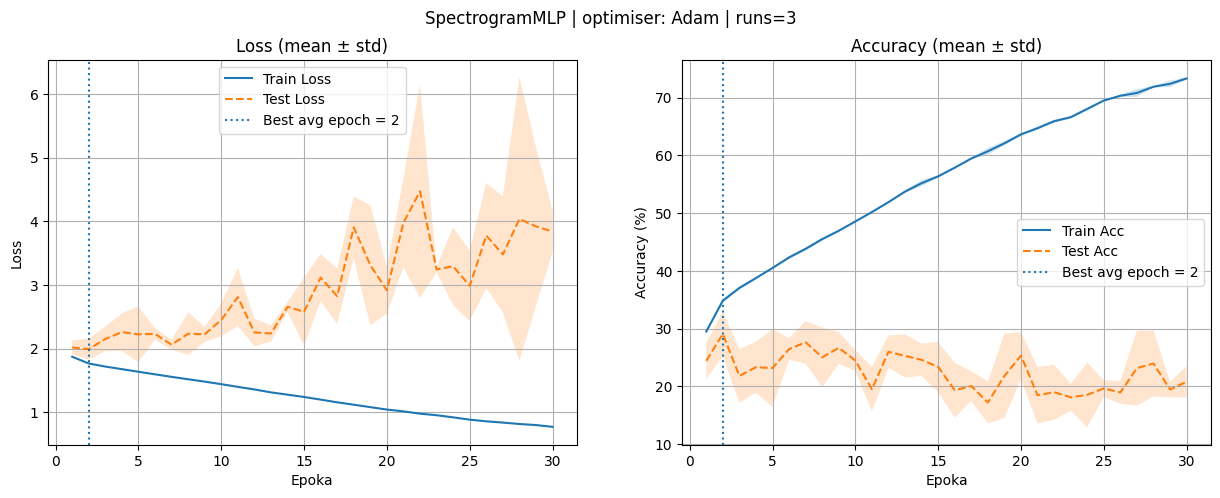


Confusion matrix (LAST RUN @ best avg epoch):
               Electronic  Experimental  Folk  Hip-Hop  Instrumental  \
Electronic            287            83     3        2            59   
Experimental          109           186     6        2           135   
Folk                   64           127    98        0           197   
Hip-Hop               308            65     1       15            12   
Instrumental           64           106    26        0           315   
International         140           204    32        2            92   
Pop                   137           108    20        4            57   
Rock                   61            46     5        1            55   

               International  Pop  Rock  
Electronic                 0    0   166  
Experimental               1    0   158  
Folk                       0    0   114  
Hip-Hop                    0    0   196  
Instrumental               0    0    89  
International              0    0   130  
Pop       

/Users/pawelmozaryn/MACHINE_LEARNING/Nonlinear_and_ml/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pawelmozaryn/MACHINE_LEARNING/Nonlinear_and_ml/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pawelmozaryn/MACHINE_LEARNING/Nonlinear_and_ml/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

{'histories': [{'train_loss': [1.8727427642943215,
    1.7600990796914735,
    1.7182606420867086,
    1.6759949131811664,
    1.6375838407736099,
    1.595187131096335,
    1.5599578168922332,
    1.5173361173609072,
    1.4851705004485587,
    1.4384739042870145,
    1.3970551716570163,
    1.3568908286979908,
    1.3146331045694235,
    1.2720596152243138,
    1.235137532092553,
    1.1976275098885802,
    1.1535429747143435,
    1.1138194938674786,
    1.0786269909648234,
    1.0352882725226664,
    1.0161499518078967,
    0.9807954735938936,
    0.9451972046741904,
    0.9190174573950833,
    0.8803630967810595,
    0.8586698835175586,
    0.8247789261885171,
    0.8150412859298012,
    0.7893531993870742,
    0.7689795512232026],
   'train_acc': [29.740300375469335,
    35.15853149770547,
    37.155819774718395,
    38.9549436795995,
    40.63934084272007,
    42.584480600750936,
    43.79954109303296,
    45.431789737171464,
    46.792866082603254,
    48.56070087609512,
    50.

In [20]:
model_training_and_eval(SpectrogramMLP, SpectrogramDataset)

### 2.1 Standardowy CNN

[KROK 1] Weryfikacja danych...
   -> Sprawdzam spójność plików...
   -> Znaleziono: 23970 plików .npy.
Using device: mps

=== RUN 1/3 (seed=42) | SpectrogramCNN | AdamW ===
Epoka 01 | Train Loss: 1.7643 Test Loss: 1.6730 | Train Acc: 33.86% Test Acc: 38.82%
Epoka 02 | Train Loss: 1.6291 Test Loss: 1.5762 | Train Acc: 41.31% Test Acc: 42.70%
Epoka 03 | Train Loss: 1.5653 Test Loss: 1.6402 | Train Acc: 44.73% Test Acc: 40.15%
Epoka 04 | Train Loss: 1.5226 Test Loss: 1.7929 | Train Acc: 46.42% Test Acc: 36.30%
Epoka 05 | Train Loss: 1.4969 Test Loss: 1.5890 | Train Acc: 47.62% Test Acc: 43.43%
Epoka 06 | Train Loss: 1.4825 Test Loss: 1.7089 | Train Acc: 48.16% Test Acc: 35.92%
Epoka 07 | Train Loss: 1.4594 Test Loss: 1.7381 | Train Acc: 49.02% Test Acc: 43.14%
Epoka 08 | Train Loss: 1.4474 Test Loss: 1.6096 | Train Acc: 49.46% Test Acc: 41.20%
Epoka 09 | Train Loss: 1.4299 Test Loss: 1.5441 | Train Acc: 50.64% Test Acc: 45.60%
Epoka 10 | Train Loss: 1.4187 Test Loss: 1.5867 | Train Acc: 5

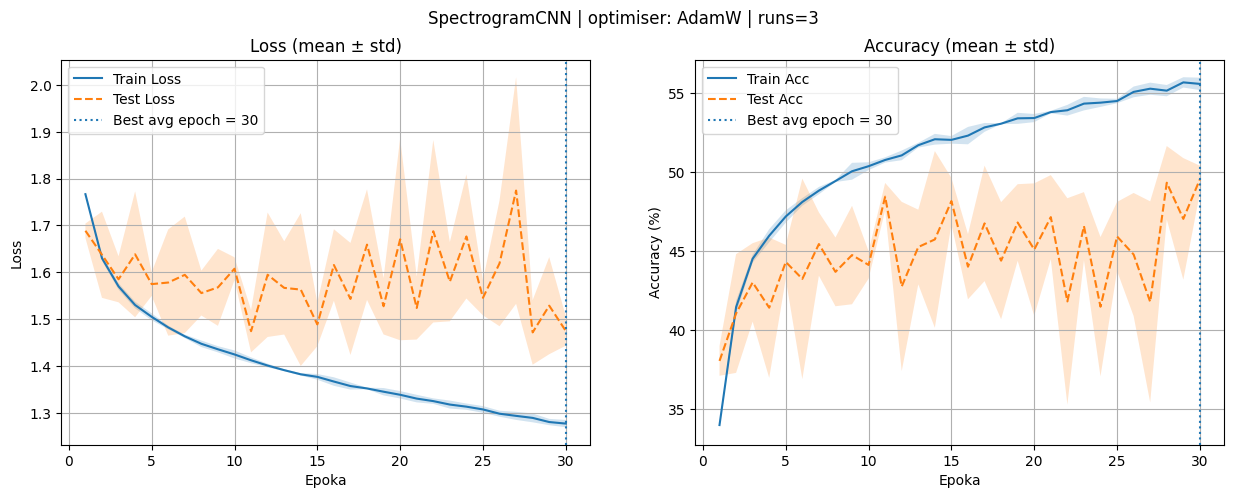


Confusion matrix (LAST RUN @ best avg epoch):
               Electronic  Experimental  Folk  Hip-Hop  Instrumental  \
Electronic            452            73     4        7            32   
Experimental           76           312    19        2           100   
Folk                   25            97   291        1            99   
Hip-Hop               248            46     0      203            22   
Instrumental           64           100    24        3           357   
International          80            69    56        9            20   
Pop                   138           117    32       10            76   
Rock                   49            99    14        0            44   

               International  Pop  Rock  
Electronic                10    7    15  
Experimental              33   13    42  
Folk                      31   16    40  
Hip-Hop                   33   24    21  
Instrumental              12    7    33  
International            325   22    19  
Pop       

{'histories': [{'train_loss': [1.764276450009559,
    1.6290768593313498,
    1.5652651013460666,
    1.5225972181367138,
    1.4969304218160941,
    1.482461267329277,
    1.4593897918686054,
    1.4474096857710685,
    1.4298575166667258,
    1.4186844793915698,
    1.4058499272087488,
    1.3989347442269673,
    1.3899694152011641,
    1.3826031110462766,
    1.3728990473745264,
    1.3599217028532318,
    1.349394536485859,
    1.3500679646326097,
    1.3408564760329875,
    1.3352198389405054,
    1.3240727904840564,
    1.323907666272007,
    1.311368194977144,
    1.3143347244636685,
    1.3023936586376026,
    1.2936795837540005,
    1.2883384026832565,
    1.2890905495429965,
    1.2804753417316257,
    1.2761188433177282],
   'train_acc': [33.86003337505215,
    41.312056737588655,
    44.72778473091364,
    46.417396745932415,
    47.622027534418024,
    48.164372131831456,
    49.02482269503546,
    49.46287025448477,
    50.641426783479346,
    50.500625782227786,
    50.9

In [21]:
model_training_and_eval(SpectrogramCNN, SpectrogramCnnDataset, optim_algo=optim.AdamW)

### 2.2 CRNN

[KROK 1] Weryfikacja danych...
   -> Sprawdzam spójność plików...
   -> Znaleziono: 23970 plików .npy.
Using device: mps

=== RUN 1/3 (seed=42) | CRNNSpectrogram | AdamW ===
Epoka 01 | Train Loss: 1.6281 Test Loss: 1.8295 | Train Acc: 40.57% Test Acc: 36.27%
Epoka 02 | Train Loss: 1.4341 Test Loss: 1.5307 | Train Acc: 49.45% Test Acc: 45.33%
Epoka 03 | Train Loss: 1.3606 Test Loss: 1.6830 | Train Acc: 52.57% Test Acc: 41.86%
Epoka 04 | Train Loss: 1.3107 Test Loss: 1.4226 | Train Acc: 54.43% Test Acc: 50.33%
Epoka 05 | Train Loss: 1.2690 Test Loss: 1.6264 | Train Acc: 56.12% Test Acc: 45.49%
Epoka 06 | Train Loss: 1.2265 Test Loss: 1.3834 | Train Acc: 57.39% Test Acc: 52.46%
Epoka 07 | Train Loss: 1.1841 Test Loss: 1.4622 | Train Acc: 58.82% Test Acc: 50.04%
Epoka 08 | Train Loss: 1.1434 Test Loss: 1.5525 | Train Acc: 60.47% Test Acc: 47.52%
Epoka 09 | Train Loss: 1.0890 Test Loss: 1.4333 | Train Acc: 62.49% Test Acc: 50.92%
Epoka 10 | Train Loss: 1.0323 Test Loss: 1.6009 | Train Acc: 

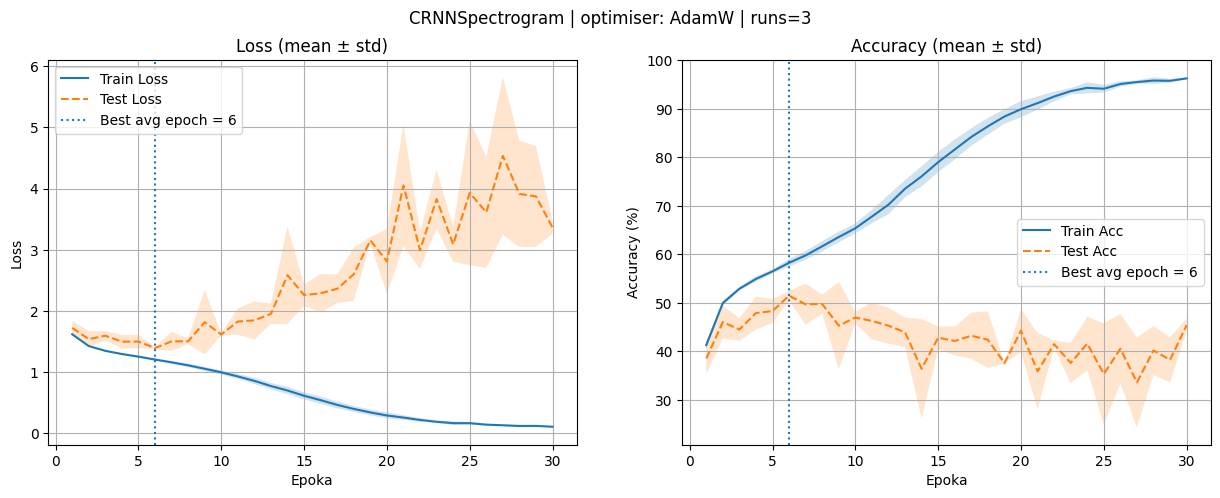


Confusion matrix (LAST RUN @ best avg epoch):
               Electronic  Experimental  Folk  Hip-Hop  Instrumental  \
Electronic            348            30    30       71            39   
Experimental           44           218    85       44            85   
Folk                    7            39   445        5            34   
Hip-Hop                42             9    16      419            14   
Instrumental           37            44   108       11           324   
International          31            21   163       44            12   
Pop                    59            22   134       58            54   
Rock                   20            36    69        2            42   

               International  Pop  Rock  
Electronic                15   60     7  
Experimental              18   84    19  
Folk                       4   62     4  
Hip-Hop                   13   77     7  
Instrumental              10   50    16  
International            251   74     4  
Pop       

{'histories': [{'train_loss': [1.6280709157449582,
    1.434135671203018,
    1.3606112157995123,
    1.310654077372752,
    1.2690409995836172,
    1.226495254621637,
    1.1840718910502155,
    1.1434176656470778,
    1.0890416140152506,
    1.032277716066522,
    0.9723839449743256,
    0.9083399194750031,
    0.8290944356295682,
    0.7617410169723982,
    0.6703832756741921,
    0.6039053528667938,
    0.5189924296310259,
    0.44594608528891555,
    0.3941248513954005,
    0.3403322914515031,
    0.29660917909930135,
    0.25297583443177557,
    0.20815300854435054,
    0.20136931417980042,
    0.19140561174292042,
    0.15143057358329576,
    0.14242661453109012,
    0.14485929633460046,
    0.1276063076704181,
    0.11483480985065425],
   'train_acc': [40.57154776804339,
    49.45244055068836,
    52.5657071339174,
    54.42740926157697,
    56.12223612849395,
    57.38944513975803,
    58.8235294117647,
    60.46620775969962,
    62.48957029620359,
    64.48164372131832,
    6

In [22]:
model_training_and_eval(CRNNSpectrogram, SpectrogramCnnDataset, optim.AdamW)

### 2.3 CNN z połączeniami rezydualnymi inspirowany siecią $ResNet18$

[KROK 1] Weryfikacja danych...
   -> Sprawdzam spójność plików...
   -> Znaleziono: 23970 plików .npy.
Using device: mps

=== RUN 1/3 (seed=42) | ResNetSpectrogram | AdamW ===
Epoka 01 | Train Loss: 1.8273 Test Loss: 1.6907 | Train Acc: 31.37% Test Acc: 37.73%
Epoka 02 | Train Loss: 1.6765 Test Loss: 1.6377 | Train Acc: 38.41% Test Acc: 41.32%
Epoka 03 | Train Loss: 1.5880 Test Loss: 1.8470 | Train Acc: 43.39% Test Acc: 34.94%
Epoka 04 | Train Loss: 1.5200 Test Loss: 1.4811 | Train Acc: 46.19% Test Acc: 48.39%
Epoka 05 | Train Loss: 1.4752 Test Loss: 1.4652 | Train Acc: 48.24% Test Acc: 47.73%
Epoka 06 | Train Loss: 1.4315 Test Loss: 1.4453 | Train Acc: 49.60% Test Acc: 49.33%
Epoka 07 | Train Loss: 1.4011 Test Loss: 1.4245 | Train Acc: 50.65% Test Acc: 49.31%
Epoka 08 | Train Loss: 1.3746 Test Loss: 1.4148 | Train Acc: 52.10% Test Acc: 50.54%
Epoka 09 | Train Loss: 1.3494 Test Loss: 1.3913 | Train Acc: 52.73% Test Acc: 51.27%
Epoka 10 | Train Loss: 1.3188 Test Loss: 1.3885 | Train Acc

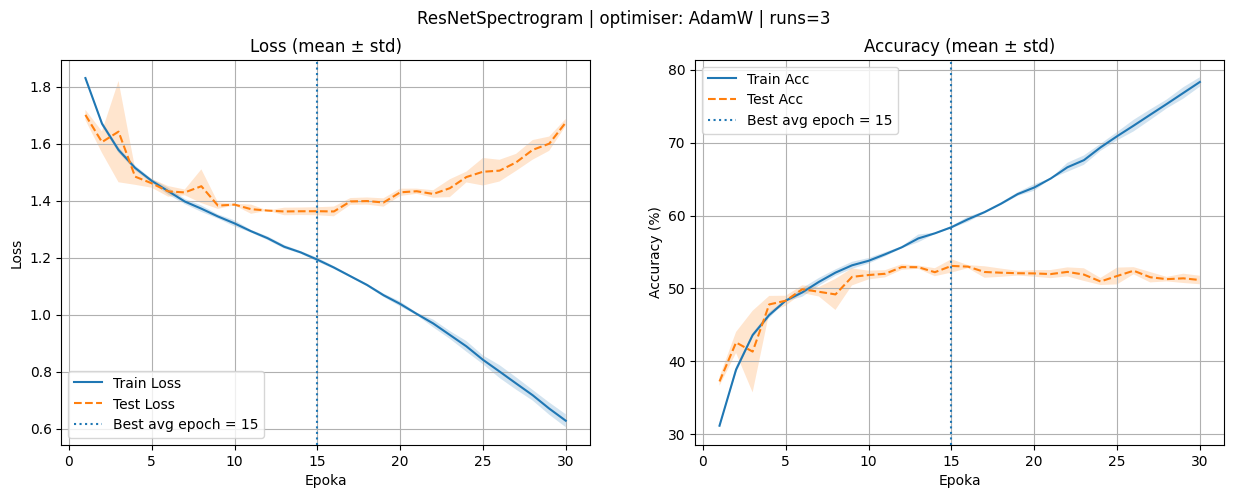


Confusion matrix (LAST RUN @ best avg epoch):
               Electronic  Experimental  Folk  Hip-Hop  Instrumental  \
Electronic            424            47    12       27            30   
Experimental           52           242    51       19            82   
Folk                   15            38   379        5            43   
Hip-Hop               126            19     6      377            12   
Instrumental           54            45    68        8           331   
International          59            21    74       49            18   
Pop                   116            25    76       59            49   
Rock                   24            44    34        9            20   

               International  Pop  Rock  
Electronic                10   24    26  
Experimental              43   38    70  
Folk                      32   33    55  
Hip-Hop                   11   28    18  
Instrumental              19   25    50  
International            301   30    48  
Pop       

{'histories': [{'train_loss': [1.8273416748134406,
    1.6765299105972462,
    1.5880368010521333,
    1.5199836348313613,
    1.4751830792297758,
    1.4315400671153253,
    1.401131681168532,
    1.3746118882719953,
    1.3493845940233022,
    1.318802254817662,
    1.2954242011135102,
    1.2664935295413722,
    1.243215850606082,
    1.2211097385866423,
    1.1956370731766741,
    1.1619569090042305,
    1.1305519734813514,
    1.103476048212127,
    1.0676761418518843,
    1.0345509307405378,
    1.0035642101509052,
    0.9640287453301708,
    0.9228905759655439,
    0.8810912829963277,
    0.8349851851270355,
    0.7938473242792329,
    0.7461909025870217,
    0.713818981441598,
    0.6717583962316358,
    0.6204973958560115],
   'train_acc': [31.372549019607842,
    38.40738423028786,
    43.38756779307467,
    46.193158114309554,
    48.24259491030455,
    49.60367125573634,
    50.65185648727576,
    52.10158531497706,
    52.73258239465999,
    53.8537755527743,
    54.995828

In [23]:
model_training_and_eval(ResNetSpectrogram, SpectrogramCnnDataset, optim.AdamW)